<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_054_partial_dependence_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 54/365 — Partial Dependence Plots (PDP)
## How does changing one feature affect the model's prediction on average?

Yesterday we learned **SHAP**, which helps explain individual predictions.

Today we move to a global interpretability tool:

**Partial Dependence Plots (PDPs)**

A PDP asks:

> On average, how does the model's prediction change as one feature changes?


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the real Diabetes dataset


In [2]:
data=load_diabetes(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

print("Dataset shape:",X.shape)
display(X.head())


Dataset shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Train a Random Forest regressor


In [3]:
model=RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

rmse=mean_squared_error(y_test,pred)**0.5
r2=r2_score(y_test,pred)

print("Test RMSE:",round(rmse,2))
print("Test R²:",round(r2,3))


Test RMSE: 53.93
Test R²: 0.474


## 3. Partial Dependence for one feature

We inspect:

`bmi`

The PDP varies BMI across a grid and averages the model's predictions.


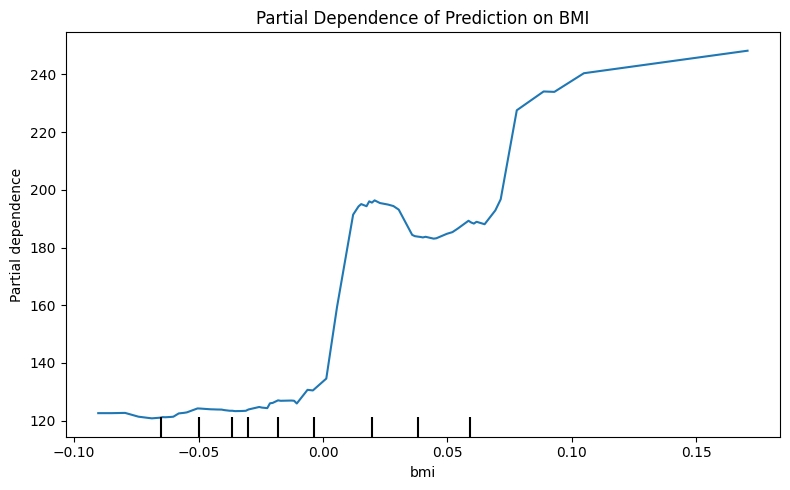

In [4]:
fig,ax=plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["bmi"],
    ax=ax
)

plt.title("Partial Dependence of Prediction on BMI")
plt.tight_layout()
plt.show()


## 4. Compare two features


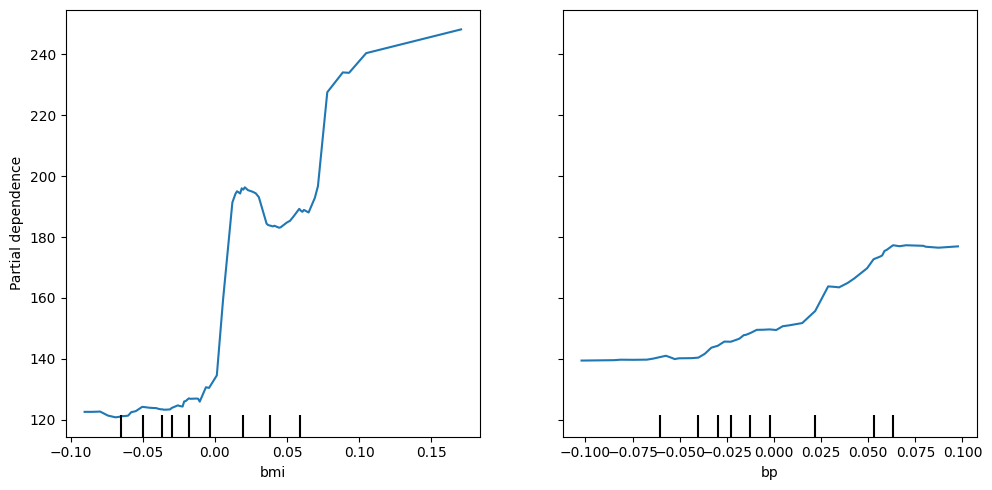

In [5]:
fig,ax=plt.subplots(figsize=(10,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["bmi","bp"],
    ax=ax
)

plt.tight_layout()
plt.show()


## 5. What does a PDP mean?

For a selected feature:

1. Choose a value.
2. Set that feature to that value across many observations.
3. Get model predictions.
4. Average those predictions.
5. Repeat across many values.

Result:

**Feature value → Average model prediction**


## Enterprise intuition

Imagine a churn model using:

`Days Since Last Login`

A PDP might show that predicted churn stays low initially, then rises sharply after a certain point.

Or a claims model may show that predicted review risk rises nonlinearly with claim amount.

PDPs can help answer:

- Is the relationship linear or nonlinear?
- Is there a threshold?
- Does the model's behaviour make business sense?


## Important limitation

PDPs can be misleading when features are strongly correlated.

Changing one feature while holding correlated features fixed can create unrealistic combinations.

So PDPs explain model behaviour, not causality, and must be read with knowledge of the data.


## SHAP vs PDP

**SHAP:** Why did the model make this specific prediction?

**PDP:** How does the model's prediction change on average as this feature changes?

They answer different questions and complement each other.


## What does this teach?

- PDP is a global interpretability technique.
- It reveals the model's average response to a feature.
- It can expose nonlinear effects and thresholds.
- It explains model behaviour, not causality.
- Correlated features can complicate interpretation.

> **SHAP explains individual decisions. PDP shows the model's overall response to a feature.**


## References

- https://scikit-learn.org/stable/modules/partial_dependence.html
- https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
